# Seaborn Regression and matrix plots

Two groups of plots, both directly useful for ML work:

- **Regression plots**: `regplot`, `lmplot`, `residplot` — fit a line through scatter data and visualize the fit.
- **Matrix plots**: `heatmap`, `clustermap` — visualize 2D matrices Correlation matrices, confusion matrices, attention weights.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(0)

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")

## regplot — scatter with a fit line

`regplot` draws a scatter plot and overlays a regression line with a
confidence interval band.


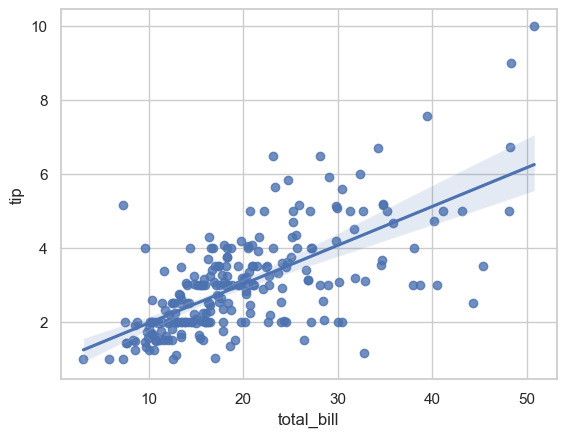

In [2]:
sns.regplot(data=tips, x="total_bill", y="tip")
plt.show()

The shaded band is the 95% confidence interval for the regression
line, not for the data. It says: "we are 95% sure the true mean line is
in this band." For tips, the line is fairly tight, suggesting the
relationship is consistent across the data.

By default `regplot` fits **ordinary least squares** — a straight line.


## heatmap — visualize a 2D matrix

A **heatmap** colors cells of a matrix by value. The two most common uses
in ML:

1. Correlation matrices — which features are related to each other.
2. Confusion matrices — how a classifier confuses one class for another.


### Correlation matrix

In [9]:
# Compute correlations across numeric columns of penguins
corr = penguins.select_dtypes("number").corr()
corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


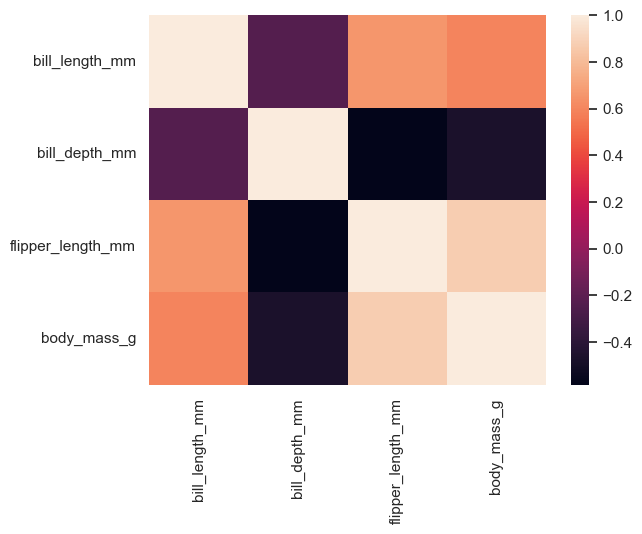

In [10]:
sns.heatmap(corr)
plt.show()

Default colormap is hard to read. The diagonal is always 1
(every variable is perfectly correlated with itself) and dominates the
color scale.

Better defaults for correlation:


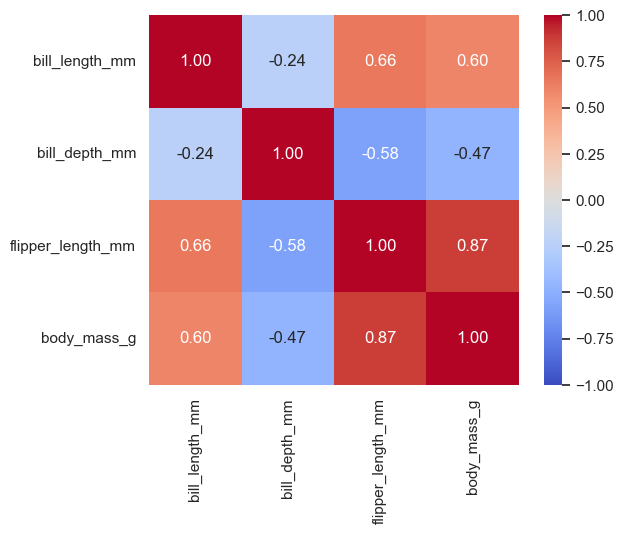

In [11]:
sns.heatmap(
    corr,
    annot=True,         # write the values in each cell
    fmt=".2f",          # 2 decimal places
    cmap="coolwarm",    # diverging palette: red/blue/white
    center=0,           # center the palette at 0
    vmin=-1, vmax=1,    # fix the color scale to the full correlation range
    square=True,
)
plt.show()

Now the visual is interpretable:
- Red = strong positive correlation
- Blue = strong negative correlation
- White = no correlation

This is the standard form. Memorize these arguments — you will use them
every time you make a correlation heatmap.


### Masking the upper triangle

For correlation matrices, the upper and lower triangles are mirror images.
Hide the upper to reduce visual clutter:


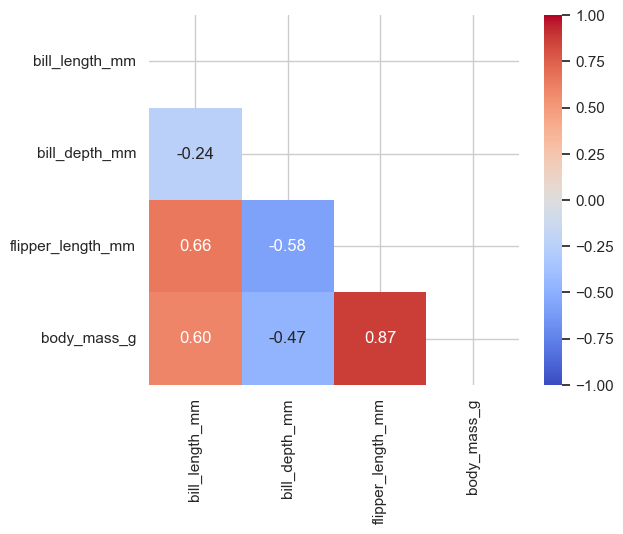

In [12]:
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
)
plt.show()

### Confusion matrix example

Building a fake confusion matrix to show the structure. Later you will
get these directly from `sklearn.metrics.confusion_matrix`.


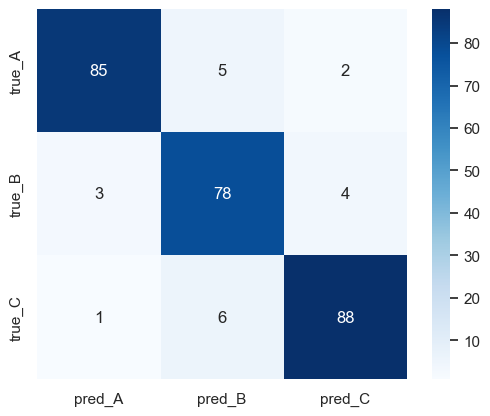

In [13]:
# Simulated 3-class confusion matrix
conf_matrix = np.array([
    [85,  5,  2],   # true=A: 85 correct, 5 predicted B, 2 predicted C
    [ 3, 78,  4],   # true=B
    [ 1,  6, 88],   # true=C
])
conf_df = pd.DataFrame(
    conf_matrix,
    index=["true_A", "true_B", "true_C"],
    columns=["pred_A", "pred_B", "pred_C"],
)

sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", square=True)
plt.show()

For confusion matrices: `cmap="Blues"` (or any sequential palette)
is conventional. `fmt="d"` formats integers.

Reading: rows are true labels, columns are predicted labels. The
diagonal is correct predictions. Off-diagonal cells show where the
model confused classes.


### Heatmap from a pivot table

`heatmap` takes a 2D structure — a pivot table is the typical way to
create one from long-format data.


In [14]:
# Reshape flights from long to wide for heatmap
flights_wide = flights.pivot(index="month", columns="year", values="passengers")
flights_wide.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


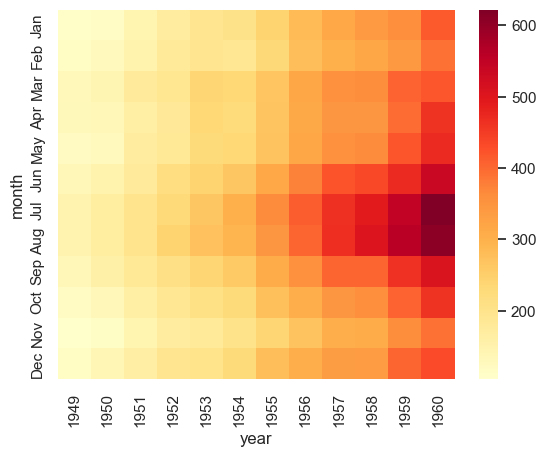

In [15]:
sns.heatmap(flights_wide, cmap="YlOrRd")
plt.show()

Quick visual story: passenger counts grow year over year (left to
right) and peak in summer months (middle rows).


## clustermap — heatmap with hierarchical clustering

`clustermap` reorders rows and columns based on similarity, grouping
similar patterns together. Useful when there is no natural order to the
rows/columns and you want to find structure.


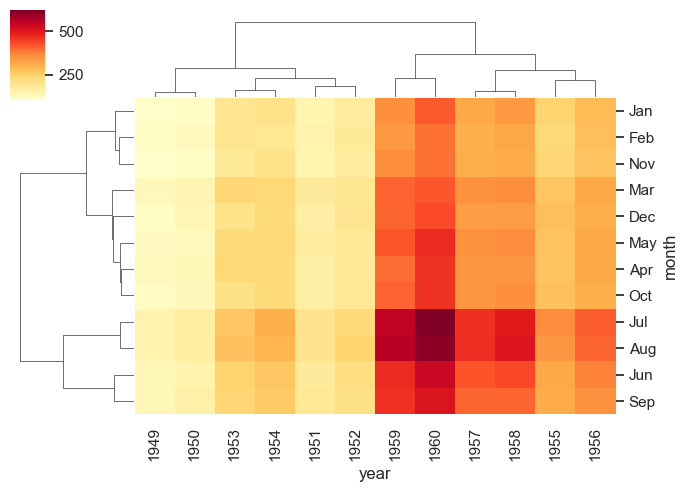

In [16]:
sns.clustermap(
    flights_wide,
    cmap="YlOrRd",
    figsize=(7, 5),
)
plt.show()

Notice that the months are now reordered — summer months grouped
together, winter months together. This is hierarchical clustering doing
its job.

For correlation matrices, clustermap reveals "feature clusters" — groups
of features that move together.



**1. Heatmap colors are easy to misread without `vmin`/`vmax`.** If you
don't set these, the color scale adapts to the data range, which can
make different plots non-comparable. Always set explicit limits for
correlation matrices (-1 to 1) and probabilities (0 to 1).

**2. `annot=True` is unreadable for large matrices.** Past about 15×15
cells, the text overflows. Drop annotations or split the matrix.

**3. Correlation heatmaps lie about non-linear relationships.** Pearson
correlation only detects linear patterns. Two variables can have a
strong quadratic relationship and zero correlation. Always look at
scatter plots too.
